# Pauli Propagation

In [1]:
import math
from functools import partial
import numpy as np
from matplotlib import pyplot as plt

from qiskit.quantum_info import Statevector, Operator
from quantum_simulation_recipe.plot_config import *
from quantum_simulation_recipe.trotter import pf
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d

from resource_estimation import *

fig_dir, data_dir = './figs', './data'
# plt.rcParams['font.family'] = 'sans-serif'
set_fontsize(linewidth=2.0)

## Pauli rotation 

Let $R_G(\theta)[P]:=e^{iG\theta/2} P e^{-iG\theta/2}$,
then 
$$R_G(\theta)[P]=P, \; [P,G]=0$$
$$R_G(\theta)[P]=\cos(\theta)P+\sin(\theta)P', \; P'=i[P,G]/2$$

In [8]:
XX = SparsePauliOp(['XX'],coeffs=[1.+0.j])
ZI = SparsePauliOp(['ZI'],coeffs=[1.+0.j])
ZZ = SparsePauliOp(['ZZ'],coeffs=[1.+0.j])
from quantum_simulation_recipe.trotter import expH 

print('XX:\n', XX.to_matrix())
print('ZI:\n', ZI.to_matrix())

theta = math.pi/8
print('theta:', theta)  
expXX = expH(XX, theta)
print('expXX:\n', expXX)
## set small number to zero by numpy setting
print('expXX[ZI]:\n', expXX @ ZI.to_matrix() @ expXX.conj().T)

analytic_expression = math.cos(theta*2)*XX + math.sin(theta*2)*commutator(XX, ZI)/2
print('Pauli rotation:', analytic_expression.simplify())

XX:
 [[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]]
ZI:
 [[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]
theta: 0.39269908169872414
expXX:
 [[0.92388+0.j       0.     +0.j       0.     +0.j       0.     -0.382683j]
 [0.     +0.j       0.92388+0.j       0.     -0.382683j 0.     +0.j      ]
 [0.     +0.j       0.     -0.382683j 0.92388+0.j       0.     +0.j      ]
 [0.     -0.382683j 0.     +0.j       0.     +0.j       0.92388+0.j      ]]
expXX[ZI]:
 [[ 0.707107+0.j        0.      +0.j        0.      +0.j
   0.      +0.707107j]
 [ 0.      +0.j        0.707107+0.j        0.      +0.707107j
   0.      +0.j      ]
 [ 0.      +0.j        0.      -0.707107j -0.707107+0.j
   0.      +0.j      ]
 [ 0.      -0.707107j  0.      +0.j        0.      +0.j
  -0.707107+0.j      ]]
Pauli rotation: SparsePauliOp(['XX', 'YX'],
         

In [9]:
# n = 10
n = 8
# t_num = 50
t_num = 100
t = n
hx, hy, Jx = 1, 1, 1
print(f'QIMF model with hx={hx}, hy={hy}, Jx={Jx}, n={n}')
# qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
qimf = Nearest_Neighbour_1d(n, hy=hy, Jx=Jx, pbc=False)
H_list = qimf.ham_par

r = t_num
dt = t/r
U_dt_ideal = expH(sum(H_list), dt, use_jax=False)
U_dt_appro = pf(H_list, dt, 1, 1)

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
commutator(qimf.ham[0], qimf.ham[3]).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j]))

QIMF model with hx=1, hy=1, Jx=1, n=8


True

In [10]:
# given a SparsePauliOp, return a list of the sum of square of coefficients of every weight of Pauli operators
def pauli_weight_norm(spo):
    """
    Calculate the norm of each weight of Pauli operators in a SparsePauliOp.
    """
    weight_norm = {}
    for pauli, coeff in zip(spo.paulis, spo.coeffs):
        # print(pauli, coeff)
        weight = sum([1 for c in pauli if str(c) != 'I'])
        # print(weight)
        if weight not in weight_norm:
            weight_norm[weight] = 0
        weight_norm[weight] += abs(coeff)**2
    return weight_norm

pauli_weight_norm(SparsePauliOp(['IIIIIIIZ', 'IIIIIIXY'], coeffs=[0.987227+0.j, 0.159318-0.j]))

{1: 0.9746171495289999, 2: 0.025382225123999996}

dt: 0.08
cumulative_norm_steps: [[1.0, 0, 0, 0, 0, 0, 0, 0], [0.9999999999999998, 0.02538229095877957, 0, 0, 0, 0, 0, 0], [0.9999999999999999, 0.097084750224491, 0, 0, 0, 0, 0, 0], [0.9999999999999999, 0.09708475022449102, 1.6352812396437687e-05, 0, 0, 0, 0, 0], [0.9999999999999999, 0.20099836410006228, 0.0002489463388218375, 0, 0, 0, 0, 0], [0.9999999999999998, 0.20099836410006228, 0.00024894633882183745, 1.0535474268550577e-08, 0, 0, 0, 0], [0.9999999999999999, 0.31630836897173586, 0.0014470607070767411, 3.60534999376251e-07, 0, 0, 0, 0], [0.9999999999999998, 0.31630836897173586, 0.0014470607070767411, 3.605349993762509e-07, 6.787591967206254e-12, 0, 0, 0], [0.9999999999999996, 0.42078920032657435, 0.005260052914803878, 4.131935060834706e-06, 4.1280560799278563e-10, 0, 0, 0], [0.9999999999999994, 0.4207892003265743, 0.00526005291480388, 4.131935060834707e-06, 4.1280560799278563e-10, 4.372978713526976e-15, 0, 0], [0.9999999999999994, 0.4963624608473067, 0.0142964226519133, 2.704903024

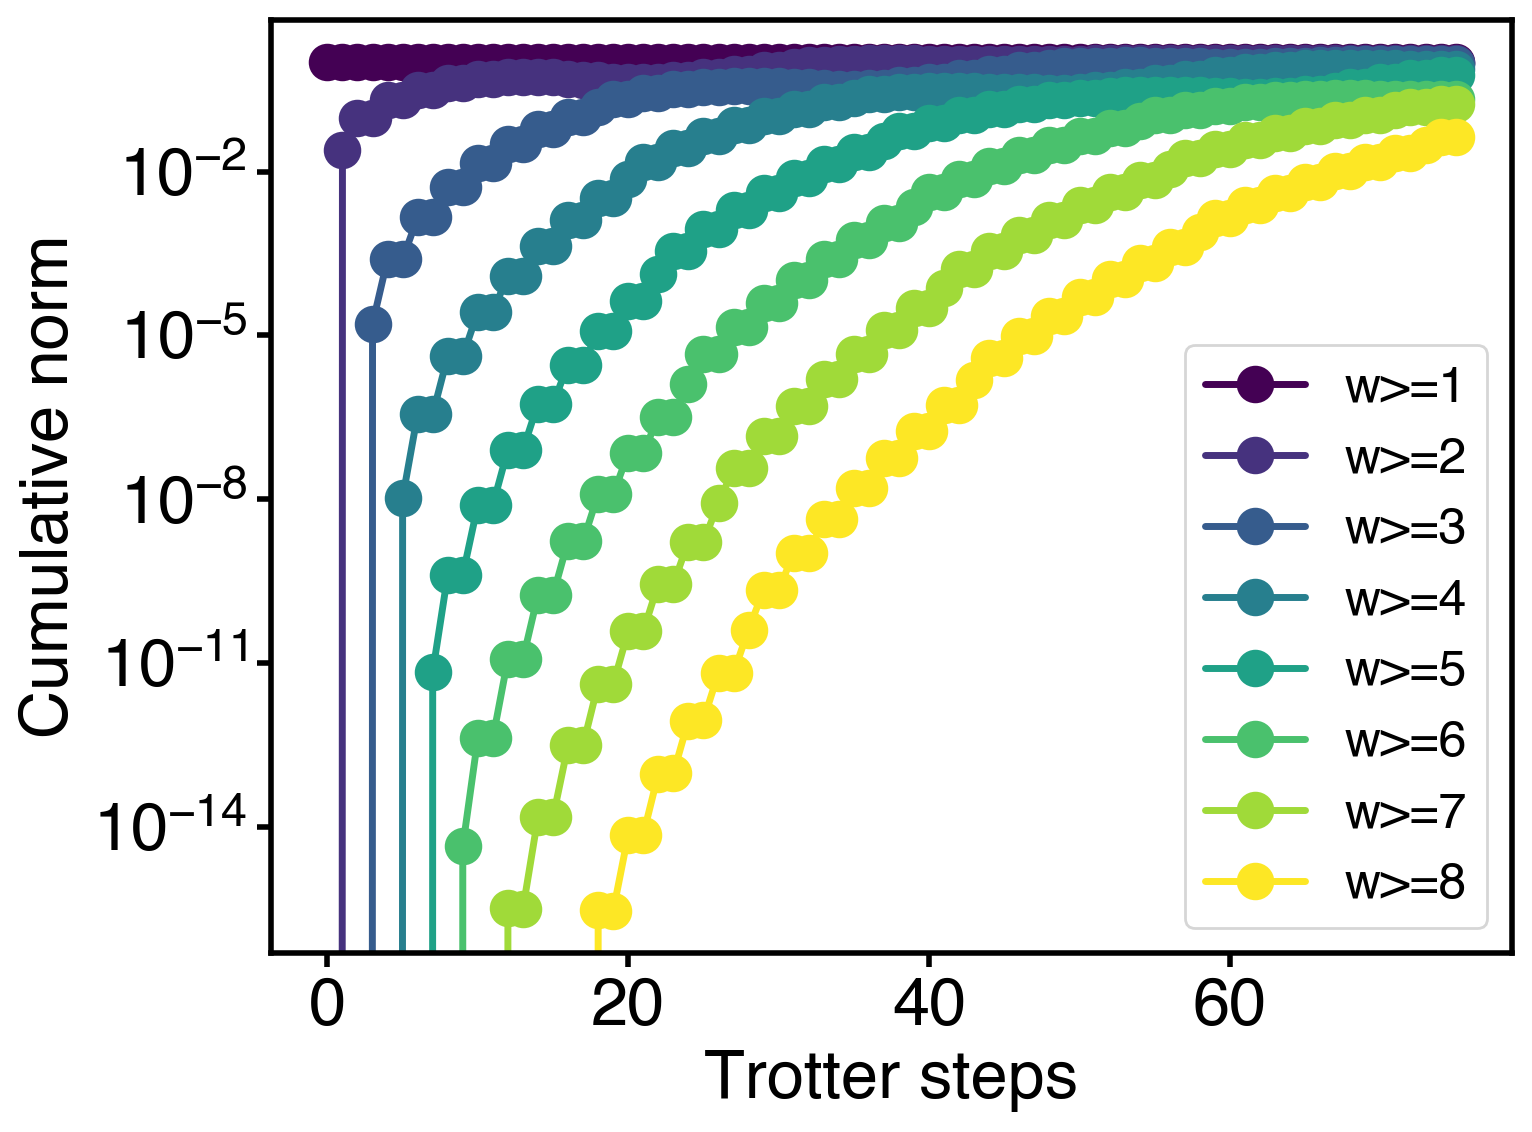

In [11]:
print('dt:', dt)
evo_ob = [z1]
for i in range(40):
    for g in list(qimf.ham):
        # print(g)
        temp = []
        for item in list(evo_ob[-1]):
            # print(item)
            if commutator(g, item).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j])):
                # print(item, g)
                temp.append(item)
            else:
                branch = math.cos(dt*2)*item + 1j*math.sin(dt*2)*g@item
                temp.append(branch)
        ob_g = sum(temp).simplify()
        # temp_step.append(ob_g)
        evo_ob.append(ob_g)
        # print(f"#Pauli={len(list(ob_g))}, 2-norm={np.linalg.norm(ob_g, ord='fro')/ np.sqrt(2**n)}")
# print('evo_ob:', evo_ob)

data_distribution = []
for item in evo_ob[::n]:
    weight_norm_dict = pauli_weight_norm(item)
    # print(len(list(item)), weight_norm_dict)
    data_distribution.append(weight_norm_dict)

cumulative_norm_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    # print(item)
    for w in range(1, n+1):
        temp_sum = 0
        for k in range(w, n+1):
            if k in item:
                # print('k', k, item[k])
                temp_sum += item[k]
        # print('sum',temp_sum)
        temp_step.append(temp_sum)
        # print(item, temp_step)
    cumulative_norm_steps.append(temp_step)
print('cumulative_norm_steps:', cumulative_norm_steps)

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(cumulative_norm_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(cumulative_norm_steps[0])):
    ax.plot(range(len(cumulative_norm_steps)), np.array(cumulative_norm_steps)[:,w], label=f'w>={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'Cumulative norm')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/cumulative_norm_steps.pdf', bbox_inches='tight')

norm_weight_steps: [[1.0, 0, 0, 0, 0, 0, 0, 0], [0.9746177090412202, 0.02538229095877957, 0, 0, 0, 0, 0, 0], [0.9029152497755089, 0.097084750224491, 0, 0, 0, 0, 0, 0], [0.9029152497755089, 0.09706839741209458, 1.6352812396437687e-05, 0, 0, 0, 0, 0], [0.7990016358999376, 0.20074941776124045, 0.0002489463388218375, 0, 0, 0, 0, 0], [0.7990016358999374, 0.20074941776124045, 0.0002489358033475689, 1.0535474268550577e-08, 0, 0, 0, 0], [0.6836916310282639, 0.31486130826465913, 0.001446700172077365, 3.60534999376251e-07, 0, 0, 0, 0], [0.6836916310282639, 0.31486130826465913, 0.001446700172077365, 3.605282117842837e-07, 6.787591967206254e-12, 0, 0, 0], [0.5792107996734253, 0.4155291474117705, 0.005255920979743043, 4.1315222552267136e-06, 4.1280560799278563e-10, 0, 0, 0], [0.5792107996734253, 0.41552914741177044, 0.005255920979743044, 4.131522255226714e-06, 4.128012350140721e-10, 4.372978713526976e-15, 0, 0], [0.5036375391526929, 0.48206603819539334, 0.01426937362167251, 2.7041183117092972e-05, 

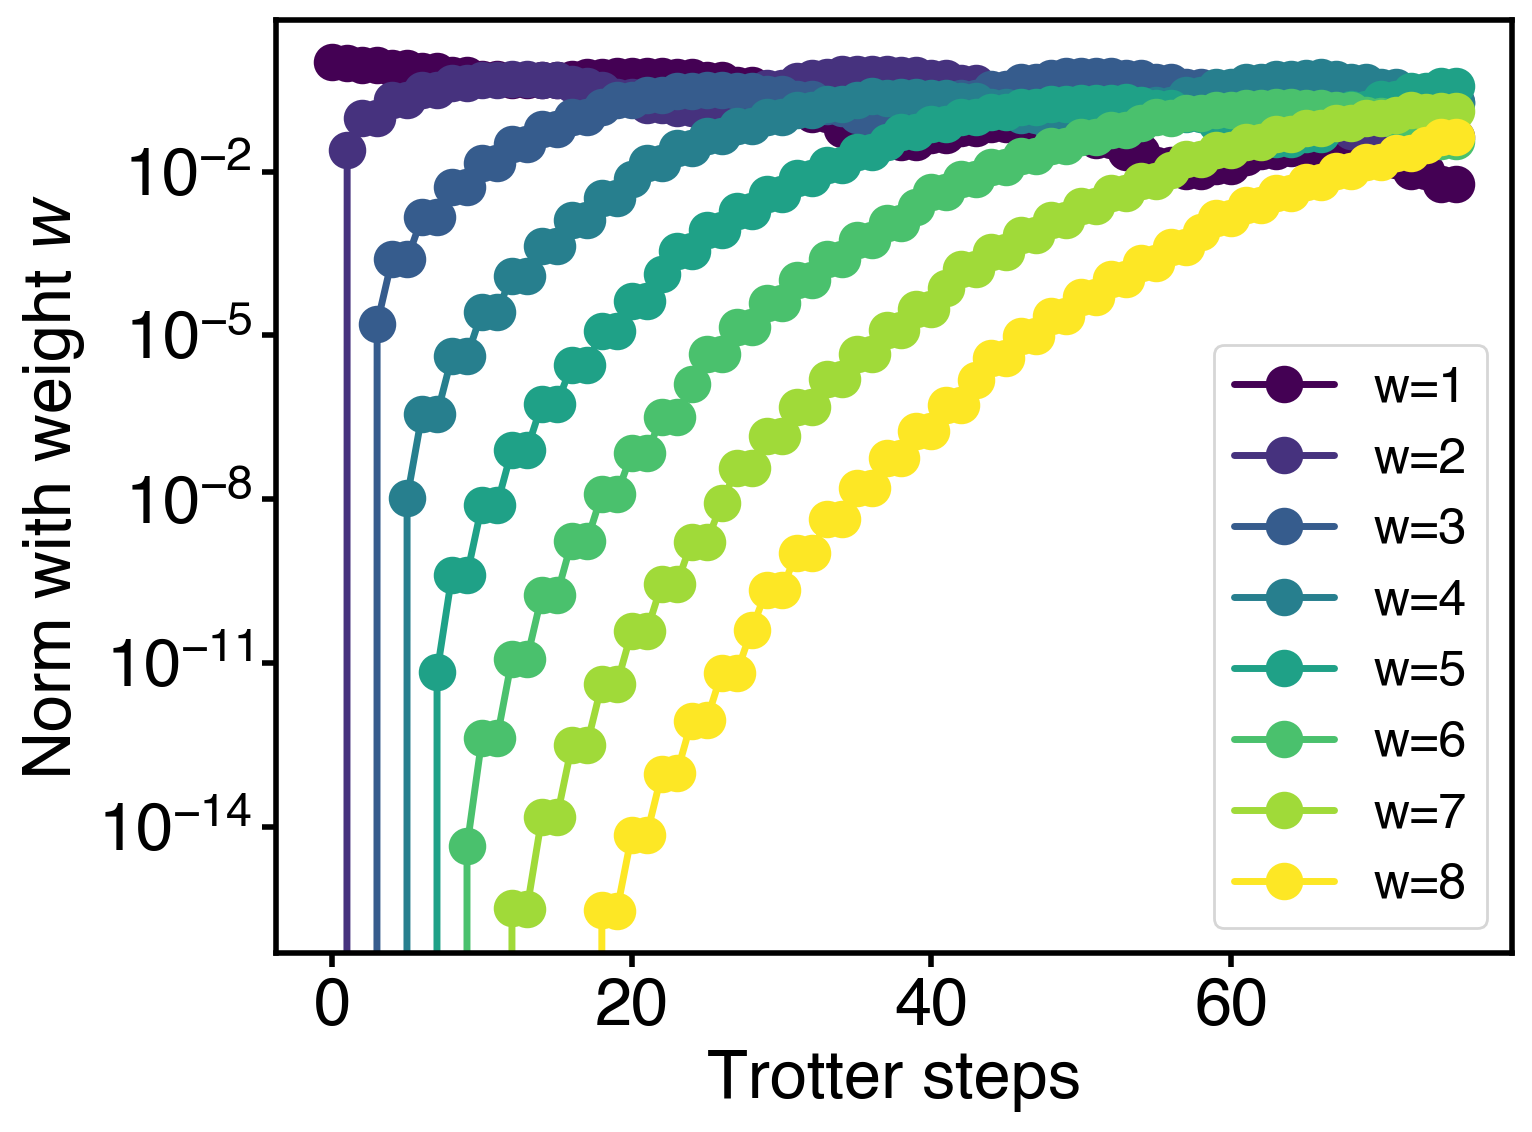

In [12]:
norm_weight_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    for w in range(1, n+1):
        if w in item:
            temp_step.append(item[w])
        else:
            temp_step.append(0)
    norm_weight_steps.append(temp_step)
print('norm_weight_steps:', norm_weight_steps)

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(norm_weight_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(norm_weight_steps[0])):
    ax.plot(range(len(norm_weight_steps)), np.array(norm_weight_steps)[:, w], label=f'w={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'Norm with weight $w$')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/norm_weight_steps.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'Pauli weight distribution')

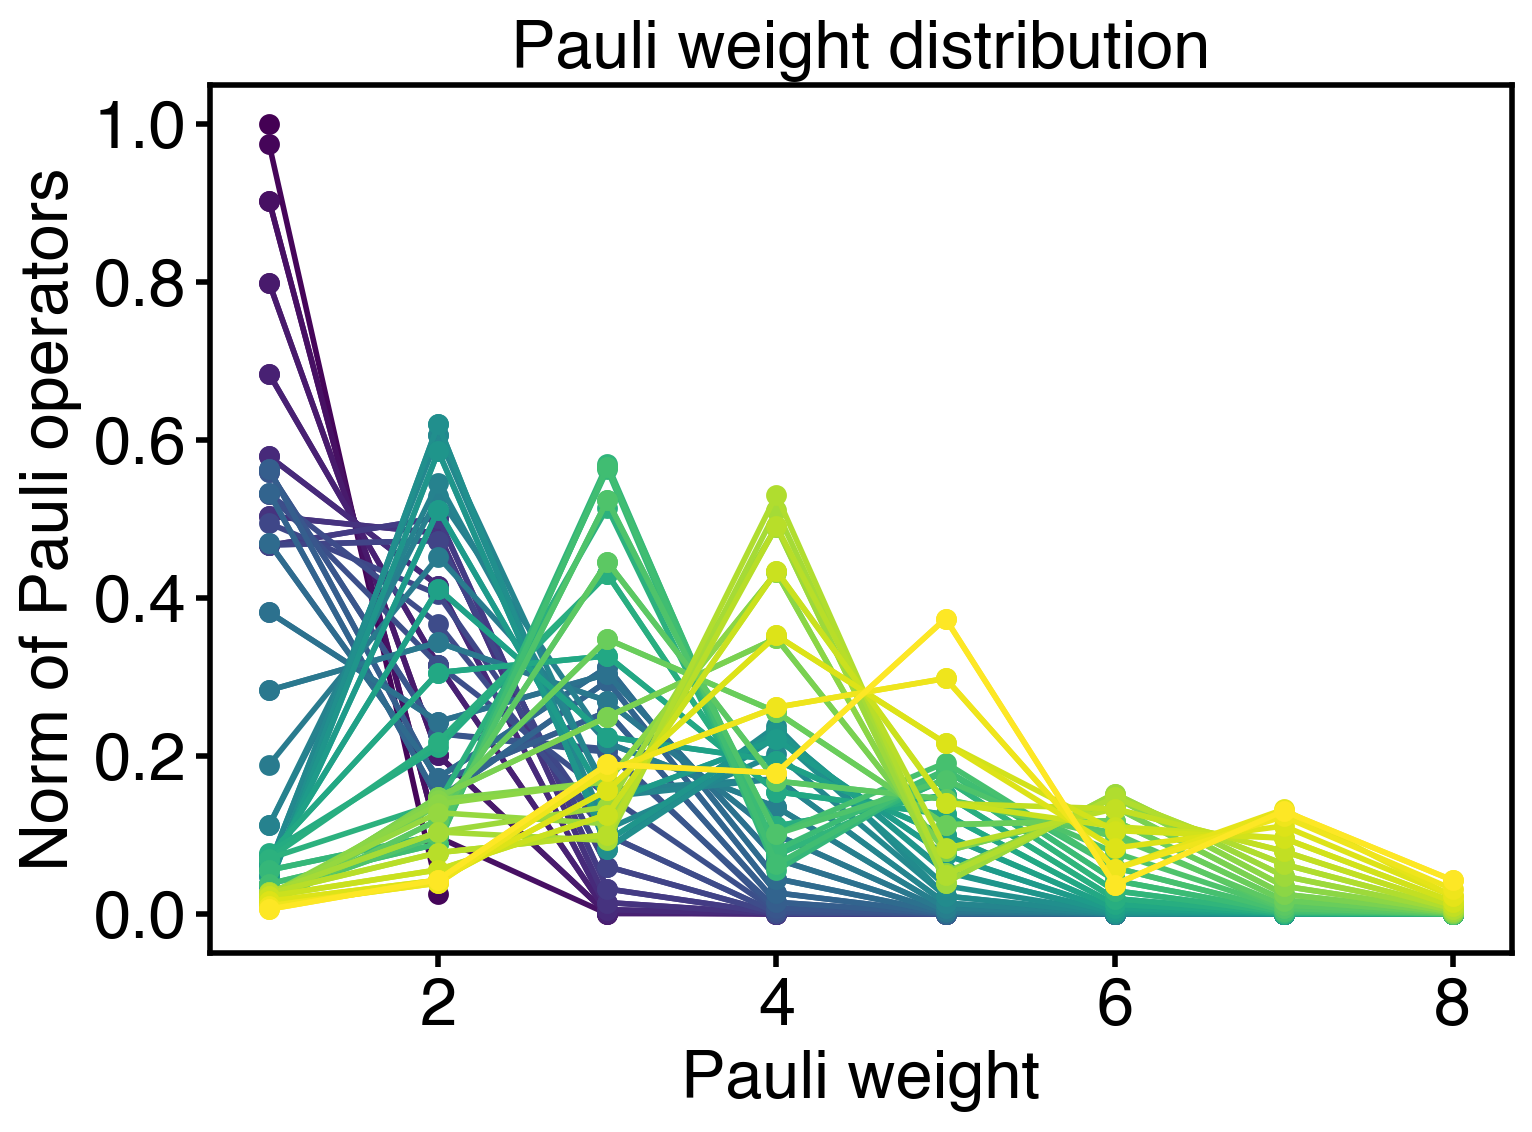

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
# use gradient color for each line
colors = plt.cm.viridis(np.linspace(0, 1, len(data_distribution)))
ax.set_prop_cycle(color=colors)
for i, item in enumerate(data_distribution):
    x = list(item.keys())
    y = [item[k] for k in x]
    ax.plot(x, y, label=f't={i*n}', marker='o', markersize=5, linewidth=2)
ax.set_xlabel('Pauli weight')
ax.set_ylabel('Norm of Pauli operators')
ax.set_title('Pauli weight distribution')

## Exact VS Trotter VS Pauli surrogate

In [9]:
import numpy as np

def expect_value(ob, state):
    # if isinstance(state, Statevector):
    #     return np.abs(state.conj().T @ ob @ state)
    # elif isinstance(state, DensityMatrix):
    #     return np.trace(ob @ state)
    # else:
    #     raise ValueError('invalid state type')
    expval = state.conj().T @ ob @ state
    if expval.imag > 1e-7:
        print('imaginary part of expectation value is', expval.imag)
        raise ValueError('Expectation value is not real')
    return expval.real
    # return np.abs(state.conj().T @ ob @ state)


QIMF model with hx=0.8, hy=0.9, Jx=1, n=10
initial state:  1010101010
++++++++++++++++++++++++++++++++++++++++++++++++++

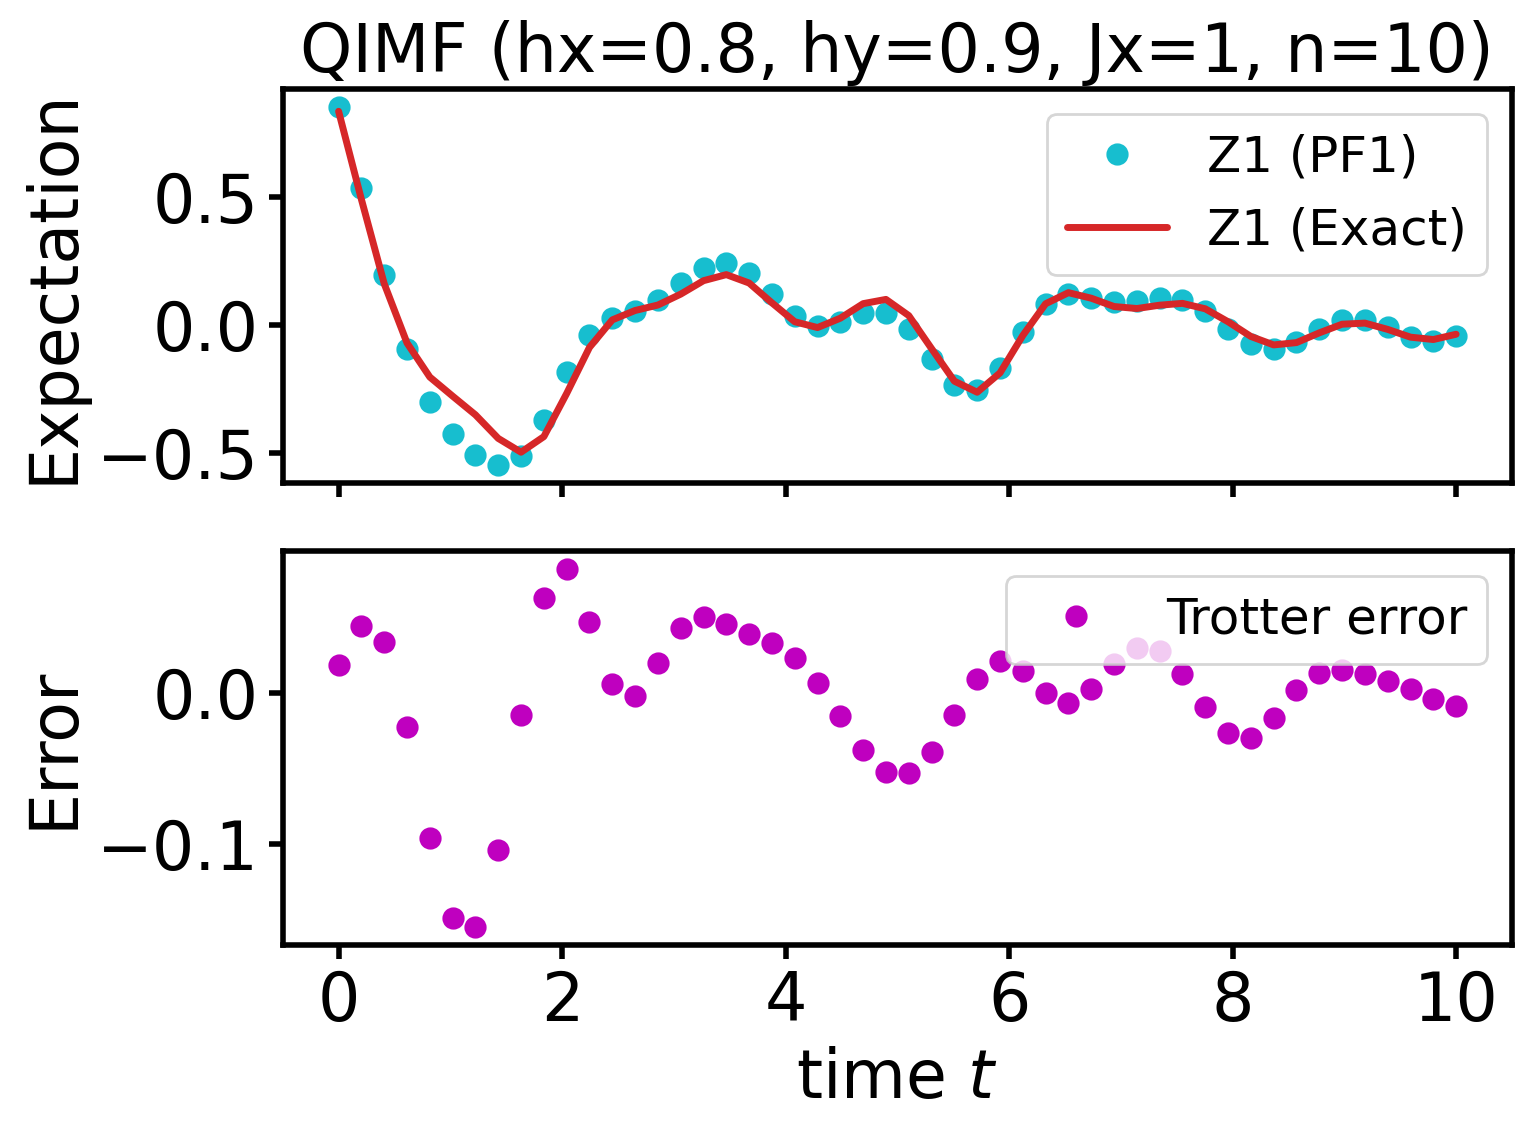

In [10]:
## QIMF model
n = 10
# n = 8
t_num = 50
# t_num = 100
t = n
t_list = np.linspace(0, t, t_num)

# hx, hy, Jx = 0.8090, 0.0, 1
hx, hy, Jx = 0.8, 0.9, 1
# hx, hy, Jx = 0.8090, 0.9045, 1
print(f'QIMF model with hx={hx}, hy={hy}, Jx={Jx}, n={n}')
qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
H_list = qimf.ham_par

r = t_num
U_dt_ideal = expH(sum(H_list), t/r, use_jax=False)
U_dt_appro = pf(H_list, t/r, 1, 1)

zzz = SparsePauliOp('Z'*n, 1).to_matrix()
xxx = SparsePauliOp('X'*n, 1).to_matrix()
# zii = SparsePauliOp('I'*(n-2)+'ZZ', 1).to_matrix()
# zii = SparsePauliOp('I'*(n-2)+'ZI', 1).to_matrix()
zii = SparsePauliOp('I'*(n-1)+'Z', 1).to_matrix()
ziz = SparsePauliOp('Z'+'I'*(n-2)+'Z', 1).to_matrix()
mag = SparsePauliOp.from_sparse_list([('Z', [i], 1/n) for i in range(0, n)], n).to_matrix()
cor = SparsePauliOp.from_sparse_list([('ZZ', [i,i+1], 1/(n-1)) for i in range(0, n-1)], n).to_matrix()

# init_state_str = '0'*n
# init_state_str = '+'*n
init_state_str = '10'*(n//2)
print('initial state: ', init_state_str)
init_state = Statevector.from_label(init_state_str).data
ideal_current_state = init_state.data
appro_current_state = init_state.data
expval_dict = {'zzz': [], 'zii': [], 'ziz': [], 'xxx': [], 'mag': [], 'cor': [], 'pf1': []}
for _ in range(r):
    print('+', end='')
    ideal_current_state = U_dt_ideal @ ideal_current_state
    appro_current_state = U_dt_appro @ appro_current_state
    # expval_dict['xxx'].append(expect_value(xxx, ideal_current_state))
    # expval_dict['zzz'].append(expect_value(zzz, ideal_current_state))
    expval_dict['zii'].append(expect_value(zii, ideal_current_state))
    expval_dict['pf1'].append(expect_value(zii, appro_current_state))
    # expval_dict['ziz'].append(expect_value(ziz, ideal_current_state))
    # expval_dict['mag'].append(expect_value(mag, ideal_current_state))
    # expval_dict['cor'].append(expect_value(cor, ideal_current_state))

fig, axes = plt.subplots(2, 1, sharex=True)
# ax.plot(t_list, expval_dict['xxx'], '-', label='xxx')
# ax.plot(t_list, expval_dict['zzz'], '-', label='zzz')
axes[0].plot(t_list, expval_dict['pf1'], '.', label='Z1 (PF1)', color='tab:cyan')
axes[0].plot(t_list, expval_dict['zii'], '-', label='Z1 (Exact)', color='tab:red')
# ax.plot(t_list, expval_dict['ziz'], '-', label='ziz')
# ax.plot(t_list, expval_dict['mag'], '-', label='mag') 
# ax.plot(t_list, expval_dict['cor'], '-', label='cor')
axes[0].set_ylabel('Expectation')
axes[1].plot(t_list, np.subtract(expval_dict['pf1'],expval_dict['zii']), '.', label='Trotter error', color='m')
axes[1].set_xlabel(rf'time $t$')
axes[1].set_ylabel('Error')
# axes[1].set_yscale('log')
axes[0].set_title(fr'QIMF (hx={hx}, hy={hy}, Jx={Jx}, n={n})')
axes[0].legend(loc='upper right'); axes[1].legend(loc='upper right')
fig.savefig(f'{fig_dir}/qimf_n={n}.pdf', bbox_inches='tight')

### Pauli string weight/coeff distribution

In [ ]:
## QTFI model
n = 8
t_num = 200
t = n
t_list = np.linspace(0, t, t_num)

# hx, hy, Jx = 0.8090, 0.0, 1